In [76]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
arquivo = pd.read_csv('C:/excel/netflix.csv')

In [77]:
arquivo.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,Device_Type,Subscription_Start_Date,Monthly_Spend_USD,Number_of_Profiles,Avg_Rating_Given,Churn_Risk_Score,Engagement_Score
0,1,Michael Williams,NaN,USA,Standard,99.671275,NaN,2024-01-01 00:00:00.000000000,NaN,2020-01-01 00:00:00.000000000,12.99,3.0,3.5,NaN,11.0
1,2,Jane Smith,35.0,Japan,Premium,99.671275,Fantasy,2024-01-01 02:37:41.746174617,Tablet,2020-01-01 05:15:32.133213321,7.99,NaN,5.0,85.0,11.0
2,3,Chris Garcia,18.0,USA,Premium,99.671275,Fantasy,2024-01-01 05:15:23.492349234,NaN,2020-01-01 10:31:04.266426642,15.99,4.0,2.0,85.0,11.0
3,4,Alex Brown,60.0,Germany,Premium,2382.147031,Animation,2024-01-01 07:53:05.238523852,NaN,2020-01-01 15:46:36.399639964,7.99,1.0,3.5,85.0,11.0
4,5,Michael Williams,25.0,UK,Basic,99.671275,Comedy,2024-01-01 10:30:46.984698469,Mobile,2020-01-01 21:02:08.532853285,9.99,1.0,1.0,85.0,NaN


In [78]:
arquivo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User_ID                  10080 non-null  int64  
 1   Name                     10080 non-null  object 
 2   Age                      9391 non-null   float64
 3   Country                  9472 non-null   object 
 4   Subscription_Type        9378 non-null   object 
 5   Watch_Time_Hours         9567 non-null   float64
 6   Favorite_Genre           9178 non-null   object 
 7   Last_Login               10080 non-null  object 
 8   Device_Type              9393 non-null   object 
 9   Subscription_Start_Date  10080 non-null  object 
 10  Monthly_Spend_USD        9892 non-null   float64
 11  Number_of_Profiles       9982 non-null   float64
 12  Avg_Rating_Given         9789 non-null   float64
 13  Churn_Risk_Score         9792 non-null   float64
 14  Engagement_Score      

In [121]:
faltantes =arquivo.isnull().sum()
print(faltantes)

User_ID                      0
Name                         0
Age                          0
Country                      0
Subscription_Type            0
Watch_Time_Hours             0
Favorite_Genre               0
Last_Login                   0
Device_Type                  0
Subscription_Start_Date      0
Monthly_Spend_USD            0
Number_of_Profiles           0
Avg_Rating_Given             0
Churn_Risk_Score             0
Engagement_Score           266
dtype: int64


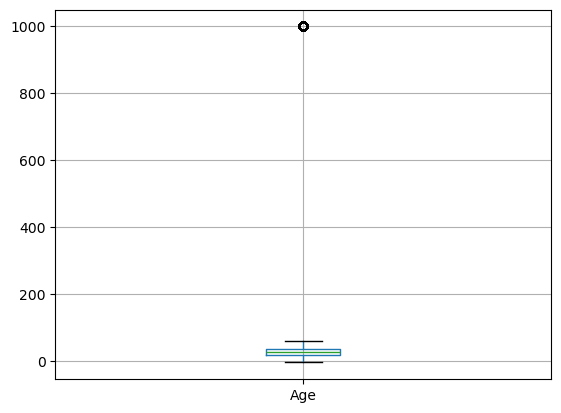

In [80]:

arquivo.boxplot(column ='Age')
plt.show()

In [81]:
arquivo = arquivo[(arquivo['Age'] >= 13) & (arquivo['Age'] <= 100)]

In [82]:
arquivo['Country'] = arquivo['Country'].fillna('Desconhecido')

In [83]:
arquivo['Subscription_Type'] = arquivo.groupby('Country')['Subscription_Type'].transform(
    lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else 'Basic')
)


In [89]:
limite = 1000
media = arquivo['Watch_Time_Hours'].mean()
arquivo.loc[arquivo['Watch_Time_Hours'] > limite, 'Watch_Time_Hours'] = media

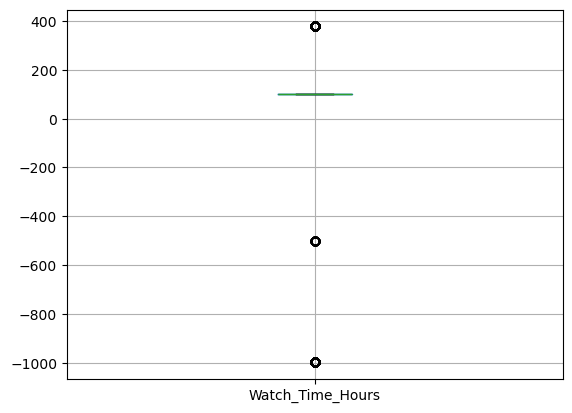

In [90]:
import matplotlib.pyplot as plt
arquivo.boxplot(column ='Watch_Time_Hours')
plt.show()

In [91]:
print(arquivo['Watch_Time_Hours'].max())

378.46640673704735


In [93]:
media = arquivo['Watch_Time_Hours'].mean()
arquivo['Watch_Time_Hours'] = arquivo['Watch_Time_Hours'].fillna(media)

In [95]:
 arquivo['Favorite_Genre'] = arquivo['Favorite_Genre'].fillna('Desconhecido')

In [96]:
arquivo['Device_Type'] = arquivo['Device_Type'].fillna('Desconhecido')

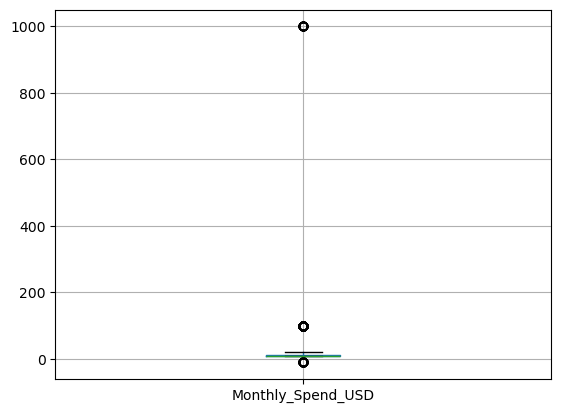

In [99]:
arquivo.boxplot(column ='Monthly_Spend_USD')
plt.show()

In [104]:
limite = arquivo['Monthly_Spend_USD'].quantile(0.99)
arquivo['Monthly_Spend_USD'] = arquivo['Monthly_Spend_USD'].clip(upper=limite)
arquivo['Monthly_Spend_USD'] = arquivo['Monthly_Spend_USD'].fillna(arquivo['Monthly_Spend_USD'].median())

print(arquivo['Monthly_Spend_USD'].max())

99.99


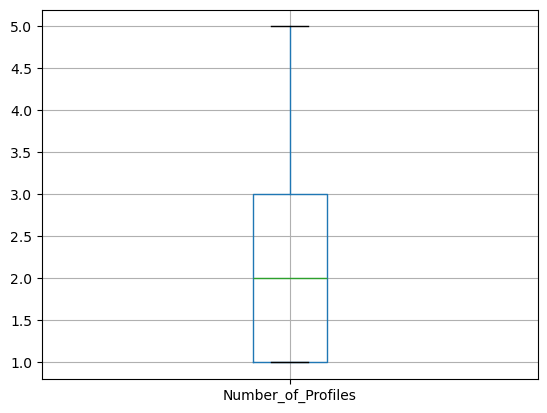

In [108]:
arquivo.boxplot(column ='Number_of_Profiles')
plt.show()

In [107]:
limite = 5
arquivo['Number_of_Profiles'] = arquivo['Number_of_Profiles'].clip(upper=limite)

In [110]:
media = arquivo['Number_of_Profiles'].mean()
arquivo['Number_of_Profiles'] = arquivo['Number_of_Profiles'].fillna(media)

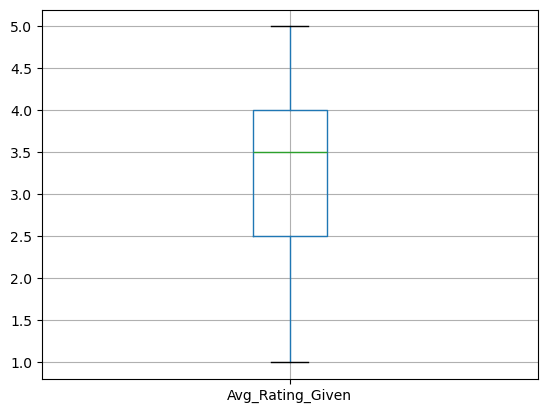

In [114]:
arquivo.boxplot(column ='Avg_Rating_Given')
plt.show()

In [113]:
limite = 5
arquivo['Avg_Rating_Given'] = arquivo['Avg_Rating_Given'].clip(upper=limite)

In [115]:
media = arquivo['Avg_Rating_Given'].mean()
arquivo['Avg_Rating_Given'] = arquivo['Avg_Rating_Given'].fillna(media)

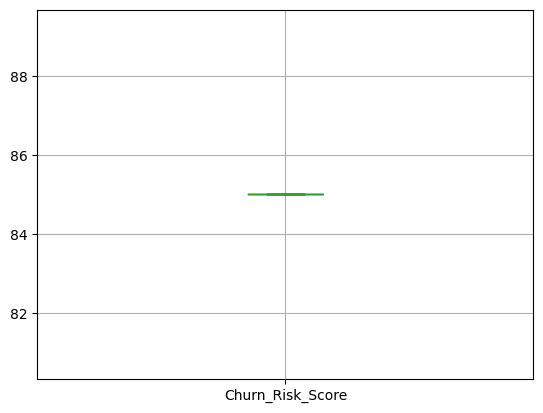

In [120]:
arquivo.boxplot(column ='Churn_Risk_Score')
plt.show()

In [118]:
print(f"Mínimo: {arquivo['Churn_Risk_Score'].min()}")
print(f"Máximo: {arquivo['Churn_Risk_Score'].max()}")
print(f"Média: {arquivo['Churn_Risk_Score'].mean():.2f}")
print(f"Mediana: {arquivo['Churn_Risk_Score'].median():.2f}")

Mínimo: -50.0
Máximo: 360.0
Média: 91.56
Mediana: 85.00


In [119]:
arquivo.loc[arquivo['Churn_Risk_Score'] < 0, 'Churn_Risk_Score'] = None
arquivo.loc[arquivo['Churn_Risk_Score'] > 100, 'Churn_Risk_Score'] = None
mediana = arquivo['Churn_Risk_Score'].median()
arquivo['Churn_Risk_Score'] = arquivo['Churn_Risk_Score'].fillna(mediana)

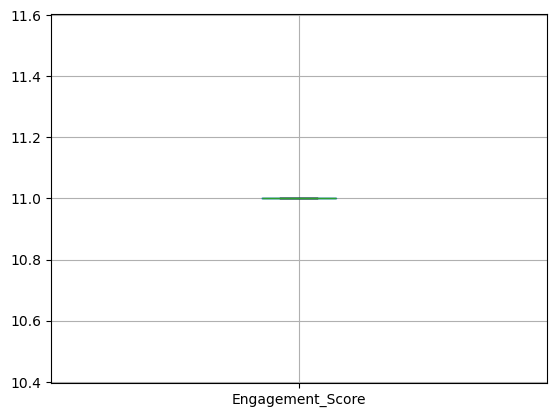

In [124]:
 arquivo.boxplot(column ='Engagement_Score')
plt.show()

In [123]:
arquivo.loc[arquivo['Engagement_Score'] < 0, 'Engagement_Score'] = None
arquivo.loc[arquivo['Engagement_Score'] > 100, 'Engagement_Score'] = None 
mediana = arquivo['Engagement_Score'].median()
arquivo['Engagement_Score'] = arquivo['Engagement_Score'].fillna(mediana)

In [125]:
arquivo.to_csv('C:/Users/ander/Desktop/Arquivos power BI/netflix_limpo_final.csv', index=False)